<a id="05"></a>

## 05 — Envelope Analysis (Square-Law Demodulation)
### Mục 1.3 (minh chứng ở mục 0.2) — Giải điều chế Envelope

**Mục đích**: minh chứng vì sao cần Envelope Analysis — tín hiệu thô/phổ
thô thường **không lộ rõ** BPFO/BPFI/BSF vì bị điều biên bởi cộng hưởng cơ
khí; phổ Envelope (sau khi giải điều chế) mới bộc lộ rõ các đỉnh này.

Công thức (đúng mục 1.3 của đề cương):

```
Envelope[n] = LowPassFilter( (x[n] * h_bandpass[n])² )
```

Notebook này cũng đối chiếu nhanh với Hilbert Transform để **kiểm tra
chéo hình dạng phổ** (không phải so sánh tài nguyên — việc đó thuộc
Giai đoạn 3, đo bằng số thật qua STM32Cube.AI/ST Edge AI Cloud).

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [ ]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = True

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [ ]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Chọn dải bandpass

**Việc quan trọng nhất của notebook này**: `BAND_HZ` bên dưới là giá trị
**ví dụ**, cần chỉnh lại dựa trên quan sát thực tế ở notebook 03 (vùng tần
số có biên độ nổi bật nhất) kết hợp tài liệu kỹ thuật SKF 6205, theo đúng
quyết định ở mục 0.4 của đề cương — không dùng phương pháp dò tự động
(Kurtogram/Spectral Kurtosis).

In [ ]:
FAULT_LABEL = "OR"
DIAMETER_MILS = 21
LOAD_HP = 0
BAND_HZ = (3200, 3800)
LP_CUTOFF_HZ = 500
FREQ_MAX_PLOT = 500

fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=LOAD_HP, diameter_mils=DIAMETER_MILS)
x = io_utils.load_de_signal(Path(fp))
rpm = cfg.NOMINAL_RPM_BY_LOAD[LOAD_HP]
print(f"File: {fp}")
print(f"RPM danh định: {rpm}")

File: ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\021\@6\234_0.mat
RPM danh định: 1797


## Phổ Envelope (Square-Law) — đánh dấu BPFO/BPFI/BSF/FTF lý thuyết

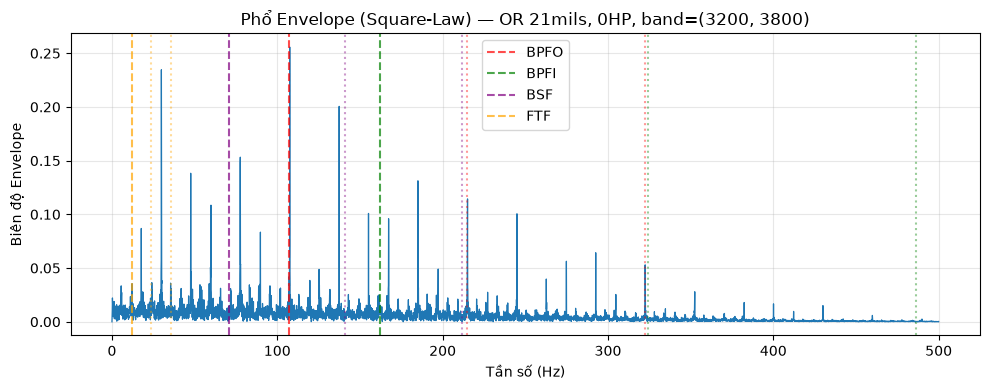

In [ ]:
envelope = dsp.square_law_envelope(x, fs=12000, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
freqs, mag = dsp.compute_fft(envelope - envelope.mean(), fs=12000)
fault_freqs = cfg.bearing_fault_frequencies(rpm)

fig, ax = plt.subplots(figsize=(10, 4))
mask = freqs <= FREQ_MAX_PLOT
ax.plot(freqs[mask], mag[mask], linewidth=0.9)

colors = {"BPFO": "red", "BPFI": "green", "BSF": "purple", "FTF": "orange"}
for name, f in fault_freqs.items():
    if name == "f_rot" or f > FREQ_MAX_PLOT:
        continue
    ax.axvline(f, color=colors.get(name, "gray"), linestyle="--", alpha=0.7, label=name)
    for h in (2, 3):
        if f * h <= FREQ_MAX_PLOT:
            ax.axvline(f * h, color=colors.get(name, "gray"), linestyle=":", alpha=0.4)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ Envelope")
ax.set_title(f"Phổ Envelope (Square-Law) — {FAULT_LABEL} {DIAMETER_MILS}mils, {LOAD_HP}HP, band={BAND_HZ}")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_spectrum_square_law.png", dpi=150)
plt.show()

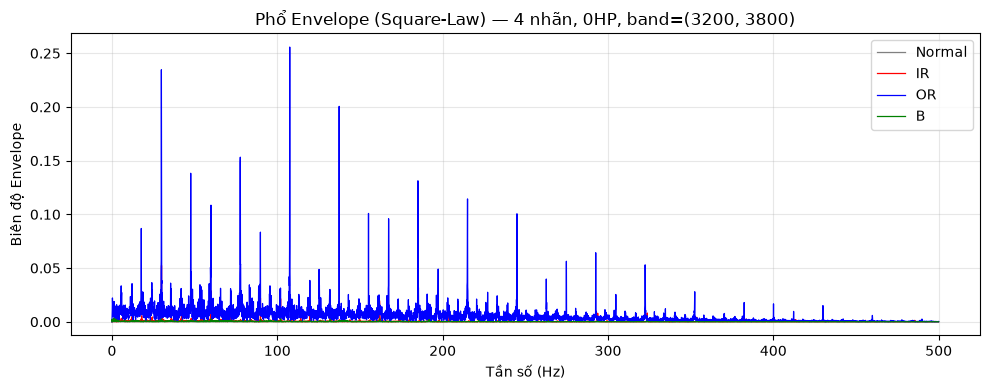

In [ ]:
label_colors = {"Normal": "gray", "IR": "red", "OR": "blue", "B": "green"}

fig, ax = plt.subplots(figsize=(10, 4))

for label, color in label_colors.items():
    if label == "Normal":
        fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP)
    else:
        fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP,
                                diameter_mils=DIAMETER_MILS)

    x = io_utils.load_de_signal(Path(fp))
    envelope = dsp.square_law_envelope(x, fs=12000, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
    freqs, mag = dsp.compute_fft(envelope - envelope.mean(), fs=12000)

    mask = freqs <= FREQ_MAX_PLOT
    ax.plot(freqs[mask], mag[mask], linewidth=0.9, color=color, label=label)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ Envelope")
ax.set_title(f"Phổ Envelope (Square-Law) — 4 nhãn, {LOAD_HP}HP, band={BAND_HZ}")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_4_labels_overlay.png", dpi=150)
plt.show()

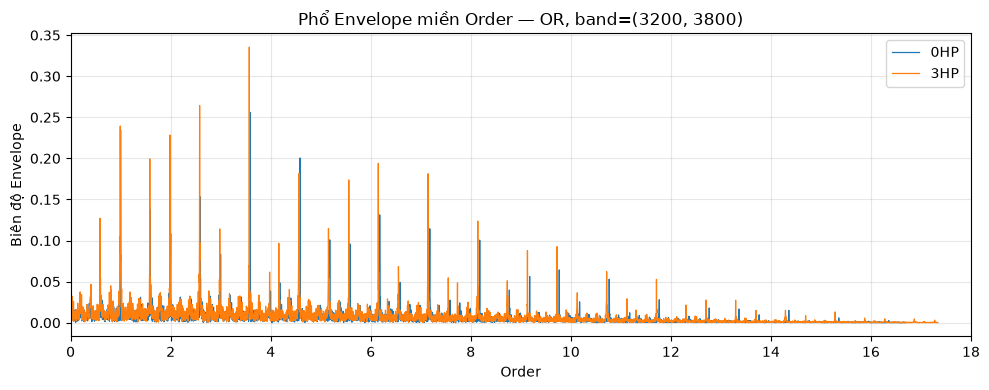

In [ ]:
ORDER_MAX_PLOT = 18

load_config = {
    0: {"color": "tab:blue",  "label": "0HP"},
    3: {"color": "tab:orange", "label": "3HP"},
}

fig, ax = plt.subplots(figsize=(10, 4))

for load_hp, lcfg in load_config.items():
    fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=load_hp,
                            diameter_mils=DIAMETER_MILS)
    x = io_utils.load_de_signal(Path(fp))
    rpm = cfg.NOMINAL_RPM_BY_LOAD[load_hp]

    envelope = dsp.square_law_envelope(x, fs=12000, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
    freqs, mag = dsp.compute_fft(envelope - envelope.mean(), fs=12000)

    orders = cfg.hz_to_order(freqs, rpm)
    mask = freqs <= FREQ_MAX_PLOT
    ax.plot(orders[mask], mag[mask], linewidth=0.9, color=lcfg["color"], label=lcfg["label"])

ax.set_xlabel("Order")
ax.set_ylabel("Biên độ Envelope")
ax.set_title(f"Phổ Envelope miền Order — {FAULT_LABEL}, band={BAND_HZ}")
ax.set_xlim(0, ORDER_MAX_PLOT)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_order_0hp_vs_3hp.png", dpi=150)
plt.show()

## Đối chiếu chéo với Hilbert Transform (chỉ kiểm tra hình dạng phổ)

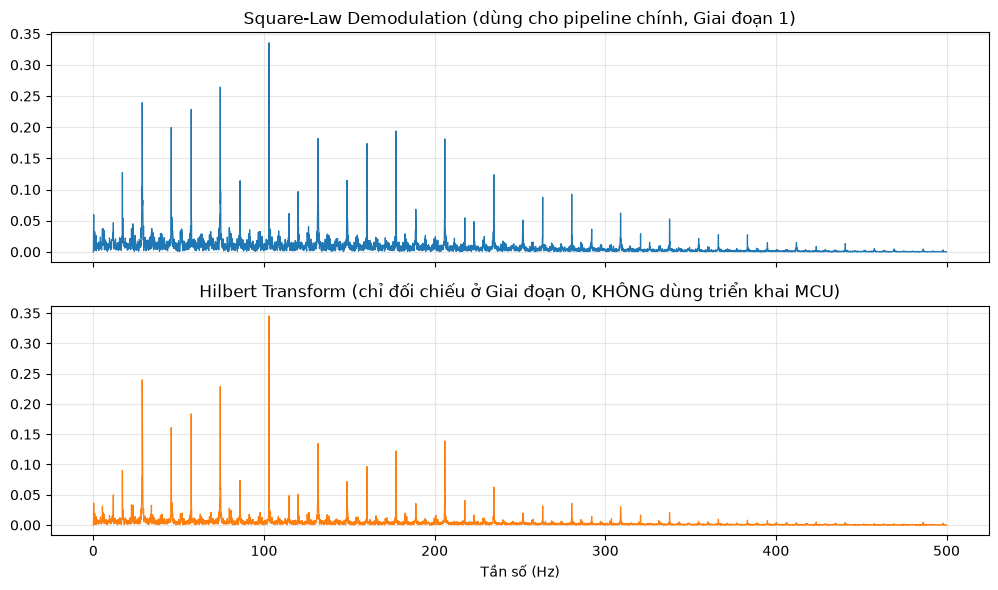

Kỳ vọng: 2 phổ có hình dạng TƯƠNG TỰ nhau (cùng vị trí đỉnh chính).
Nếu khác biệt rõ rệt, kiểm tra lại BAND_HZ hoặc bậc lọc trước khi chốt band.


In [ ]:
envelope_hilbert = dsp.hilbert_envelope(x, fs=12000, band=BAND_HZ)
freqs_h, mag_h = dsp.compute_fft(envelope_hilbert - envelope_hilbert.mean(), fs=12000)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
mask = freqs <= FREQ_MAX_PLOT
axes[0].plot(freqs[mask], mag[mask], linewidth=0.9, color="tab:blue")
axes[0].set_title("Square-Law Demodulation (dùng cho pipeline chính, Giai đoạn 1)")
axes[0].grid(alpha=0.3)

mask_h = freqs_h <= FREQ_MAX_PLOT
axes[1].plot(freqs_h[mask_h], mag_h[mask_h], linewidth=0.9, color="tab:orange")
axes[1].set_title("Hilbert Transform (chỉ đối chiếu ở Giai đoạn 0, KHÔNG dùng triển khai MCU)")
axes[1].set_xlabel("Tần số (Hz)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_squarelaw_vs_hilbert.png", dpi=150)
plt.show()

print("Kỳ vọng: 2 phổ có hình dạng TƯƠNG TỰ nhau (cùng vị trí đỉnh chính).")
print("Nếu khác biệt rõ rệt, kiểm tra lại BAND_HZ hoặc bậc lọc trước khi chốt band.")

## Quan sát & quyết định

- Ghi lại `BAND_HZ` cuối cùng đã chốt và lý do (quan sát phổ + tài liệu
  SKF 6205) — đây là thông tin bắt buộc phải có trong báo cáo (mục 0.4).
- Xác nhận đỉnh BPFO/BPFI/BSF (tùy nhãn đang xét) lộ rõ hơn hẳn so với phổ
  thô ở notebook 03.

Hình đã lưu tại `outputs/figures/05_envelope_spectrum_square_law.png` và
`05_envelope_squarelaw_vs_hilbert.png`.